In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import librosa
import librosa.display
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings("ignore")

In [4]:
BASE_DIR   = Path("/kaggle/input/competitions/birdclef-2026")
TRAIN_CSV  = BASE_DIR / "train.csv"
TAXON_CSV  = BASE_DIR / "taxonomy.csv"
LABELS_CSV = BASE_DIR / "train_soundscapes_labels.csv"
SAMPLE_SUB = BASE_DIR / "sample_submission.csv"
AUDIO_DIR  = BASE_DIR / "train_audio"
SOUNDSCAPE = BASE_DIR / "train_soundscapes"

In [5]:
plt.style.use("seaborn-v0_8-whitegrid")
PALETTE = sns.color_palette("viridis", 10)

In [6]:
train    = pd.read_csv(TRAIN_CSV)
taxonomy = pd.read_csv(TAXON_CSV)
labels   = pd.read_csv(LABELS_CSV)
sub      = pd.read_csv(SAMPLE_SUB)

print(f"  Train samples  : {len(train):,}")
print(f"  Unique species : {train['primary_label'].nunique()}")
print(f"  Taxonomy rows  : {len(taxonomy)}")
print(f"  Labeled segs   : {len(labels):,}")
print(f"  Sub columns    : {len(sub.columns)} (1 row_id + {len(sub.columns)-1} species)")
print()
print(train.head(3).to_string())
print()

  Train samples  : 35,549
  Unique species : 206
  Taxonomy rows  : 234
  Labeled segs   : 1,478
  Sub columns    : 235 (1 row_id + 234 species)

  primary_label secondary_labels type  latitude  longitude scientific_name   common_name class_name  inat_taxon_id         author   license  rating                                                           url                 filename collection
0       1161364               []   []  -22.7562   -46.8666    Guyalna cuta  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0  https://static.inaturalist.org/sounds/1216197.mp3?1727581626  1161364/iNat1216197.ogg       iNat
1       1161364               []   []  -22.7558   -46.8700    Guyalna cuta  Guyalna cuta    Insecta        1161364  Lucas Barbosa  cc-by-nc     0.0  https://static.inaturalist.org/sounds/1114648.mp3?1719714347  1161364/iNat1114648.ogg       iNat
2       1161364               []   []  -22.7547   -46.8728    Guyalna cuta  Guyalna cuta    Insecta        1161364  

Taxonomy Overview:

In [7]:
class_counts = taxonomy["class_name"].value_counts()
print(class_counts.to_string())
print()

class_name
Aves        162
Amphibia     35
Insecta      28
Mammalia      8
Reptilia      1



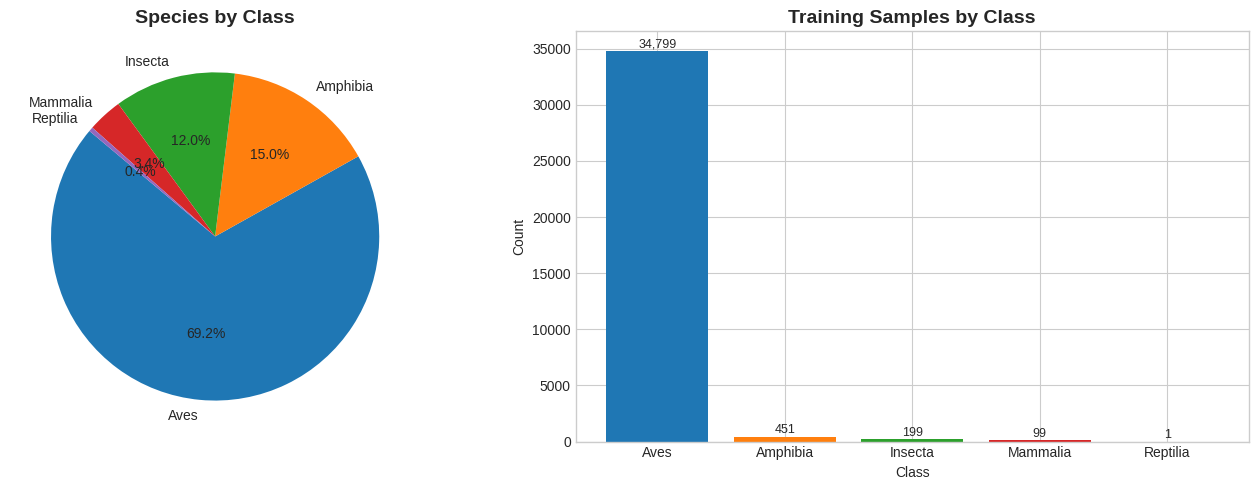

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    colors=sns.color_palette("tab10", len(class_counts)),
    startangle=140,
)
axes[0].set_title("Species by Class", fontsize=14, fontweight="bold")

if "class_name" in train.columns:
    class_sample_counts = train["class_name"].value_counts()
else:
    tax_cols = taxonomy.columns.tolist()
    print(f"  Taxonomy columns: {tax_cols}")
    class_col = next((c for c in tax_cols if "class" in c.lower()), None)
    if class_col:
        merged = train.merge(
            taxonomy[["primary_label", class_col]].rename(columns={class_col: "class_name"}),
            on="primary_label", how="left"
        )
    else:
        merged = train.copy()
        merged["class_name"] = "Unknown"
    class_sample_counts = merged["class_name"].value_counts()
axes[1].bar(
    class_sample_counts.index,
    class_sample_counts.values,
    color=sns.color_palette("tab10", len(class_sample_counts)),
)

axes[1].set_title("Training Samples by Class", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
for i, (k, v) in enumerate(class_sample_counts.items()):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("taxonomy_overview.png", dpi=150)
plt.show()

### Class Imbalance

In [12]:
species_counts = train["primary_label"].value_counts()
print(f"  Max samples per species : {species_counts.max():,}  ({species_counts.idxmax()})")
print(f"  Min samples per species : {species_counts.min():,}  ({species_counts.idxmin()})")
print(f"  Median                  : {species_counts.median():.0f}")
print(f"  Species with ≤5 samples : {(species_counts <= 5).sum()}")
print(f"  Species with ≥100 samples: {(species_counts >= 100).sum()}")

  Max samples per species : 499  (rubthr1)
  Min samples per species : 1  (516975)
  Median                  : 125
  Species with ≤5 samples : 18
  Species with ≥100 samples: 124


  Max samples per species : 499  (rubthr1)
  Min samples per species : 1  (516975)
  Median                  : 125
  Species with ≤5 samples : 18
  Species with ≥100 samples: 124


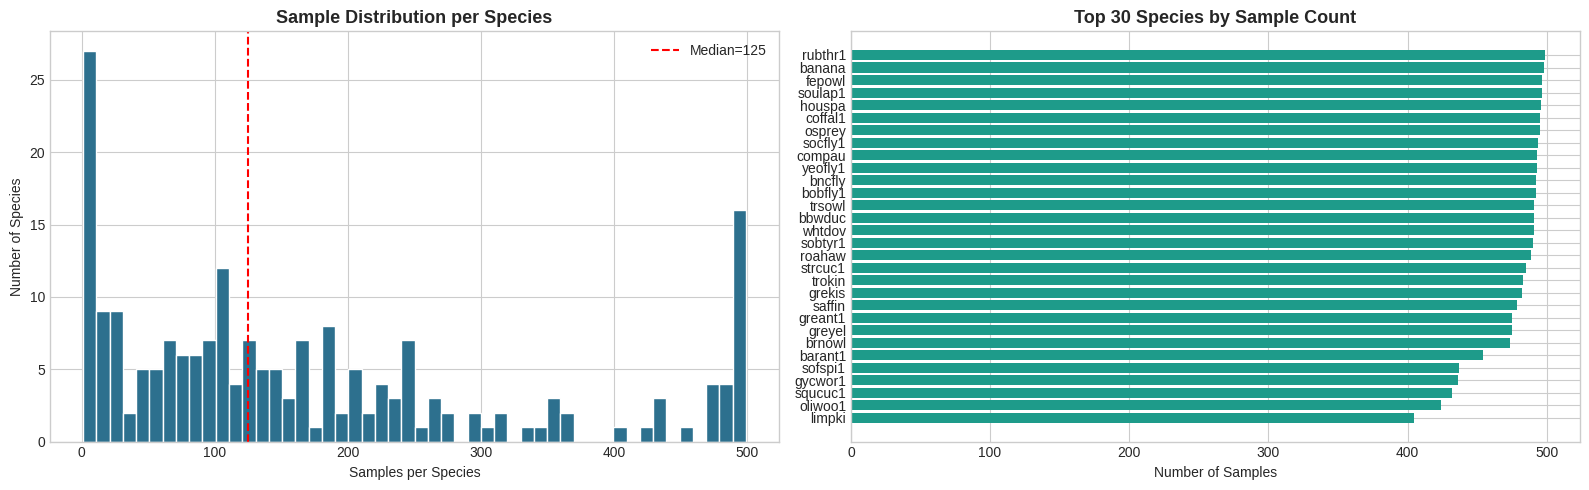

In [16]:
species_counts = train["primary_label"].value_counts()
print(f"  Max samples per species : {species_counts.max():,}  ({species_counts.idxmax()})")
print(f"  Min samples per species : {species_counts.min():,}  ({species_counts.idxmin()})")
print(f"  Median                  : {species_counts.median():.0f}")
print(f"  Species with ≤5 samples : {(species_counts <= 5).sum()}")
print(f"  Species with ≥100 samples: {(species_counts >= 100).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution histogram
axes[0].hist(species_counts.values, bins=50, color=PALETTE[3], edgecolor="white")
axes[0].set_xlabel("Samples per Species")
axes[0].set_ylabel("Number of Species")
axes[0].set_title("Sample Distribution per Species", fontsize=13, fontweight="bold")
axes[0].axvline(species_counts.median(), color="red", linestyle="--", label=f"Median={species_counts.median():.0f}")
axes[0].legend()

# Top-30 / bottom-30
top30 = species_counts.head(30)
axes[1].barh(top30.index[::-1], top30.values[::-1], color=PALETTE[5])
axes[1].set_xlabel("Number of Samples")
axes[1].set_title("Top 30 Species by Sample Count", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("class_imbalance.png", dpi=150)
plt.show()


### Audio Quality ratings:

rating
0.0    12849
0.5       22
1.0      147
1.5      120
2.0      598
2.5      518
3.0     2738
3.5     1509
4.0     8018
4.5     2185
5.0     6845

  % unrated (0) : 36.1%


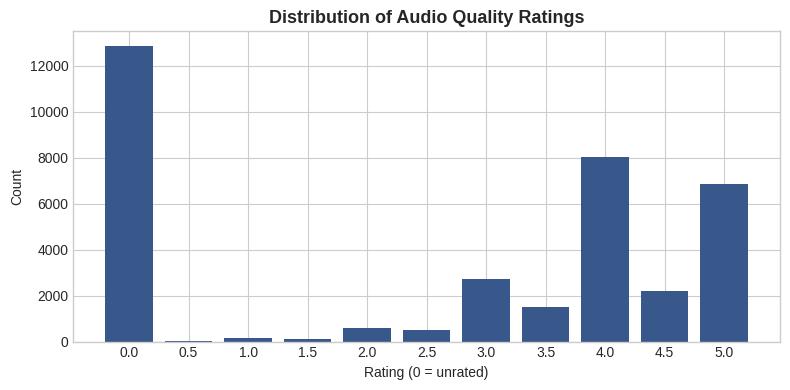

In [17]:
rating_counts = train["rating"].value_counts().sort_index()
print(rating_counts.to_string())
print(f"\n  % unrated (0) : {(train['rating'] == 0).mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rating_counts.index.astype(str), rating_counts.values, color=PALETTE[2])
ax.set_title("Distribution of Audio Quality Ratings", fontsize=13, fontweight="bold")
ax.set_xlabel("Rating (0 = unrated)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("rating_distribution.png", dpi=150)
plt.show()

### Geographic Distribution

  Recordings with geo-coords : 35,549 / 35,549


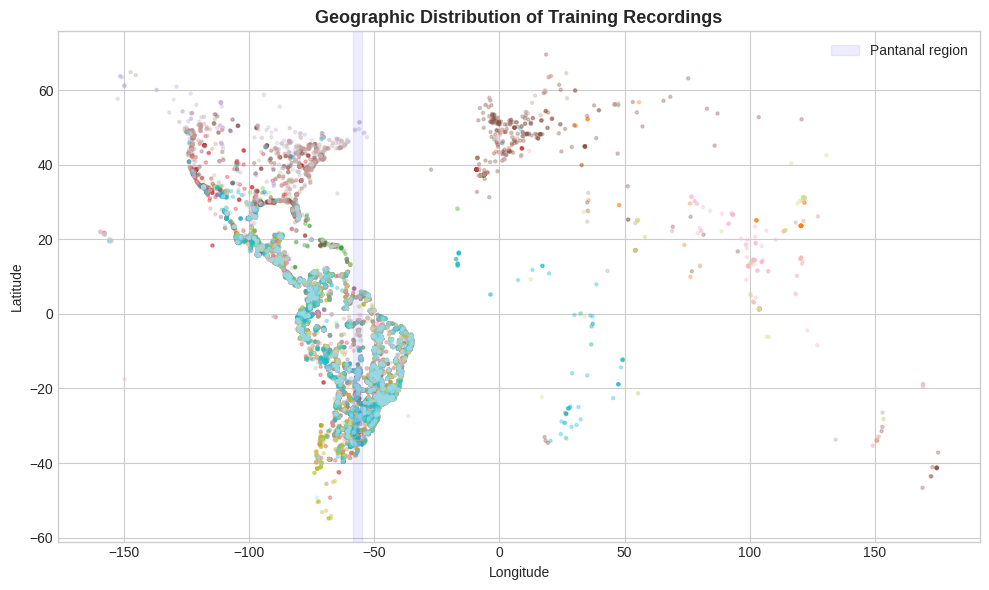

In [18]:
geo = train.dropna(subset=["latitude", "longitude"])
print(f"  Recordings with geo-coords : {len(geo):,} / {len(train):,}")

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    geo["longitude"], geo["latitude"],
    c=geo["primary_label"].astype("category").cat.codes,
    alpha=0.3, s=5, cmap="tab20"
)
ax.set_title("Geographic Distribution of Training Recordings", fontsize=13, fontweight="bold")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.axvspan(-58.5, -55.0, alpha=0.07, color="blue", label="Pantanal region")
ax.legend()
plt.tight_layout()
plt.savefig("geo_distribution.png", dpi=150)
plt.show()

In [19]:
coll = train["collection"].value_counts()
print(coll.to_string())

collection
XC      23043
iNat    12506


### Labeled Soundscapes Analysis

In [20]:
print(f"  Labeled segments : {len(labels):,}")
print(f"  Unique files     : {labels['filename'].nunique()}")

def count_labels(series):
    all_labels = []
    for row in series.dropna():
        all_labels.extend(str(row).split(";"))
    return Counter(all_labels)

soundscape_species = count_labels(labels["primary_label"])
print(f"  Unique species in soundscapes : {len(soundscape_species)}")

train_species = set(train["primary_label"].unique())
soundscape_only = {s for s in soundscape_species if s not in train_species}
print(f"  Species ONLY in soundscapes  : {len(soundscape_only)}")
if soundscape_only:
    print(f"  Examples: {list(soundscape_only)[:5]}")

  Labeled segments : 1,478
  Unique files     : 66
  Unique species in soundscapes : 75
  Species ONLY in soundscapes  : 28
  Examples: ['47158son20', '47158son11', '47158son10', '47158son18', '47158son25']


###  Audio visualization

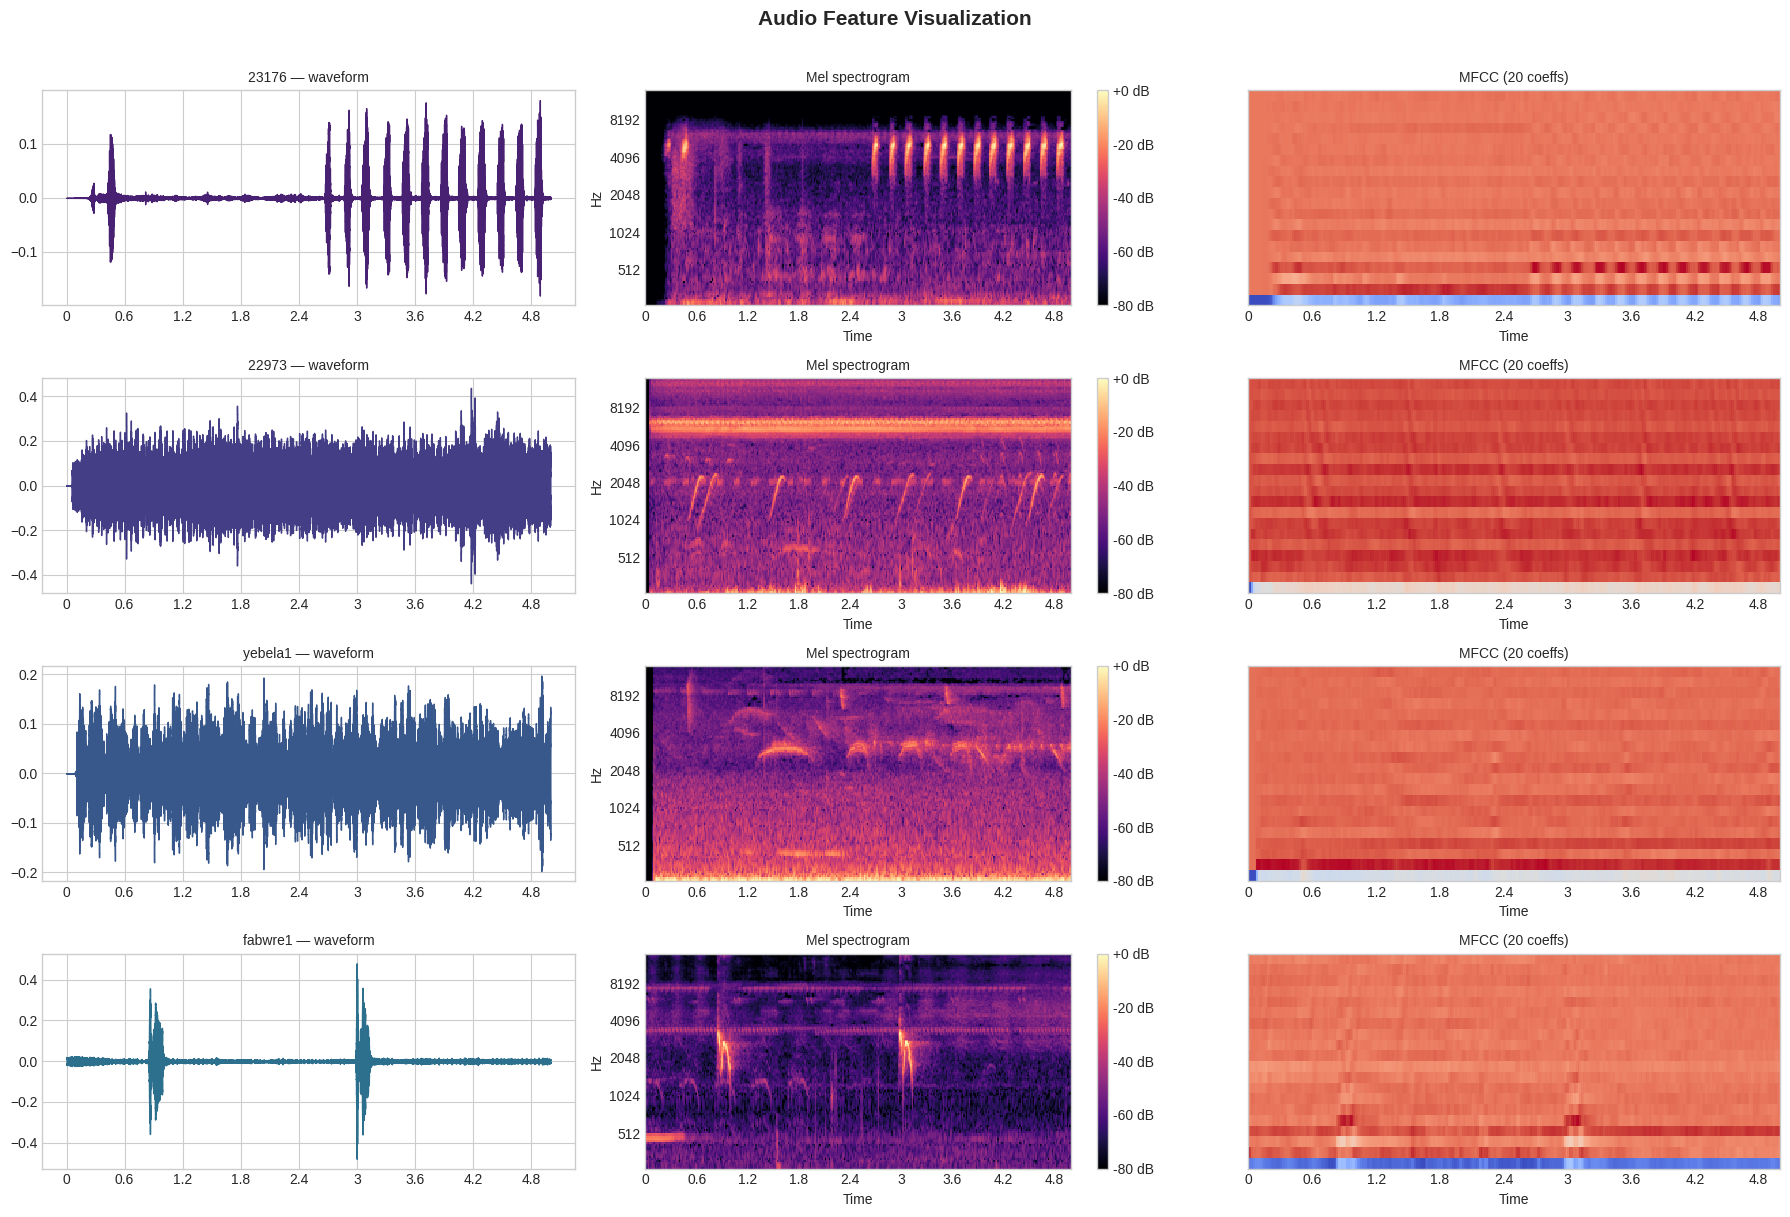

In [21]:
sample_files = train.groupby("primary_label").first().reset_index()
sample_files = sample_files.sample(4, random_state=42)

fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(4, 3, figure=fig)

SR       = 32_000
DURATION = 5.0
N_MELS   = 128
HOP_LEN  = 512
N_FFT    = 1024

for idx, (_, row) in enumerate(sample_files.iterrows()):
    fpath = AUDIO_DIR / row["filename"]
    if not fpath.exists():
        print(f"  File not found: {fpath}")
        continue

    y, sr = librosa.load(fpath, sr=SR, duration=DURATION)
    if len(y) < sr:
        print(f"  Too short: {fpath}")
        continue

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LEN,
        fmin=50, fmax=14_000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    ax_w = fig.add_subplot(gs[idx, 0])
    librosa.display.waveshow(y, sr=sr, ax=ax_w, color=PALETTE[idx])
    ax_w.set_title(f"{row['primary_label']} — waveform", fontsize=10)
    ax_w.set_xlabel("")

    ax_m = fig.add_subplot(gs[idx, 1])
    img = librosa.display.specshow(
        mel_db, sr=sr, hop_length=HOP_LEN,
        x_axis="time", y_axis="mel", ax=ax_m,
        fmin=50, fmax=14_000, cmap="magma"
    )
    ax_m.set_title(f"Mel spectrogram", fontsize=10)
    fig.colorbar(img, ax=ax_m, format="%+2.0f dB")

    ax_c = fig.add_subplot(gs[idx, 2])
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    librosa.display.specshow(mfcc, sr=sr, hop_length=HOP_LEN, x_axis="time", ax=ax_c, cmap="coolwarm")
    ax_c.set_title("MFCC (20 coeffs)", fontsize=10)

plt.suptitle("Audio Feature Visualization", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("audio_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
